<a href="https://colab.research.google.com/github/aayushka1/Data-Science-Learning/blob/main/Performance_Metrics_for_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Performance Metrics for Classification

Classification is a supervised machine learning technique used to predict discrete class labels, such as whether a patient has diabetes or not. After training a classification model, it is important to evaluate its performance using appropriate metrics instead of relying solely on accuracy. Different metrics provide different insights into how well the model classifies the data, especially when working with imbalanced datasets.

In this notebook, a Logistic Regression classifier is implemented using the Pima Indians Diabetes Dataset. The dataset is first preprocessed by separating the features and target variable, splitting the data into training and testing sets, and applying feature scaling to ensure all features are on a similar scale. The trained model is then evaluated using several commonly used classification performance metrics.

The following topics are covered in this notebook:
- Introduction to the Pima Indians Diabetes Dataset
- Data preprocessing
- Train-test split
- Feature scaling using StandardScaler
- Logistic Regression model training
- Model evaluation using:
  - Accuracy
  - Confusion Matrix
  - Precision
  - Recall
  - F1-Score
  - Binary Cross-Entropy (Log Loss)

The objective of this notebook is to understand how different evaluation metrics measure the performance of a classification model and to learn when each metric should be used for assessing classification results.

In [30]:
import itertools

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
dataset = pd.read_csv('https://drive.google.com/uc?id=1__yrQ5T2qvKylHIhZUCTk93O_Kam0JvU')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [32]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [33]:
# Import train_test_split from sklearn.model_selection and StandardScaler from sklearn.preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dataset.drop('Outcome', axis=1)
y = dataset['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# Import LogisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

LogisticRegression()

In [35]:
y_pred = logistic_regression.predict(X_test)
pd.DataFrame(y_pred)

,0
0,0
1,0
2,0
3,0
4,1
...,...
226,0
227,0
228,0
229,0


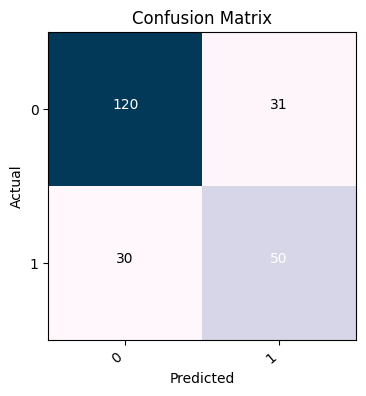

In [40]:
# Import confusion_matrix from sklearn.metrics
from sklearn.metrics import confusion_matrix

labels = y_test.unique()
matrix = confusion_matrix(y_test, y_pred, labels=labels, normalize=None)

fig,ax = plt.subplots(figsize=(12,4))
ax.imshow(matrix, cmap="PuBu")
t_hold = (matrix.max() - matrix.min()) / 2.
for row,col in itertools.product(range(len(labels)), range(len(labels))):
    color = "white" if matrix[row,col] > t_hold else "black"
    ax.text(col, row, matrix[row, col], horizontalalignment="center", color=color)
tick_marks = np.arange(len(labels))
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right")
ax.set_ylabel("Actual")
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
plt.show()


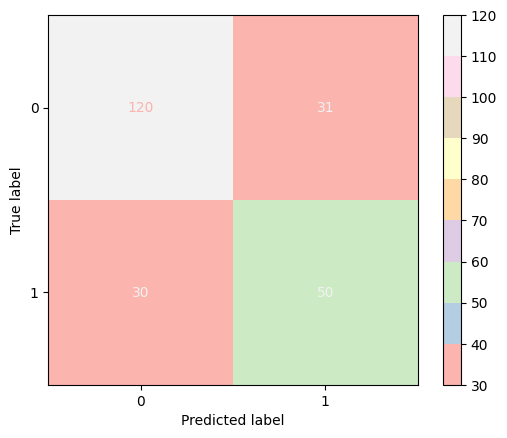

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
    logistic_regression,
    X_test,
    y_test,
    cmap="Pastel1"
)

plt.show()

In [ ]:
# Import accuracy_score from sklearn.metrics
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7359307359307359


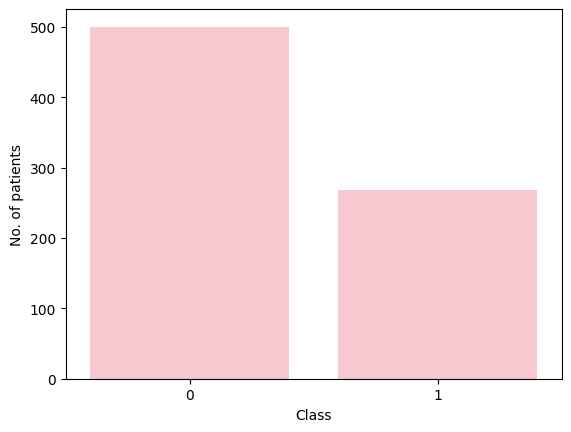

In [26]:
sns.countplot(x='Outcome', data=dataset, color="pink")
plt.xlabel("Class")
plt.ylabel("No. of patients")
plt.show()

In [ ]:
# Import precision_score from sklearn.metrics

from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(precision)

0.6172839506172839


In [ ]:
# Import precision_score from sklearn.metrics

from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(precision)

0.6172839506172839


In [ ]:
# Import f1_score from sklearn.metrics
from sklearn.metrics import f1_score

f1_score = f1_score(y_test, y_pred)
print(f1_score)

0.6211180124223602


In [ ]:
from sklearn.metrics import log_loss

# True binary labels and predicted probabilities
y_true = [0, 1, 1, 0]
y_pred = [0.9, 0.1, 0.1, 0.9]

loss = log_loss(y_true, y_pred)
print("Binary Cross-Entropy:", loss)




Binary Cross-Entropy: 2.302585092994046
